In [ ]:
import os, glob
import pandas as pd
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# -----------------------------------------------
# 基础路径
# -----------------------------------------------
DATA_ROOT = "/content/drive/MyDrive/thesis_data/Wind Farm B/datasets"
csv_paths = glob.glob(os.path.join(DATA_ROOT, "**", "*.csv"), recursive=True)


In [ ]:
# =========================================================
# 读取 CSV：构造 data_by_session 真源
# 目的：
#   1) 保留每个原始 event/session
#   2) 在 session 内按原始 time_stamp 排序
#   3) 添加 source_pos，记录原始 session 内位置
#   4) 后续基于 raw SCADA 数值生成 scada_hash
# =========================================================


data_by_session = {}          # 真源：(asset_id, session_id) -> DataFrame
buckets = defaultdict(list)   # 可选：仅用于 sanity check / 回看

for p in csv_paths:
    df = pd.read_csv(p, sep=';')

    sid = os.path.basename(p)
    aid = int(df['asset_id'].iloc[0])

    # 保留原始来源信息
    df['asset_id'] = aid
    df['session_id'] = sid
    df['time_stamp'] = pd.to_datetime(df['time_stamp'])

    # 只在当前 session 内按原始匿名 time_stamp 排序
    # 这一步只是恢复该 CSV 内部顺序，不是跨 session 排序
    df = df.sort_values('time_stamp').reset_index(drop=True)

    # source_pos = 当前 row 在这个原始 session 中的位置
    # 后面判断 duplicated block 是否连续，要靠它
    df['source_pos'] = np.arange(len(df), dtype=np.int64)

    # 唯一来源行 ID，方便后面追踪
    df['source_row_uid'] = (
        df['asset_id'].astype(str)
        + "|"
        + df['session_id'].astype(str)
        + "|"
        + df['source_pos'].astype(str)
    )

    data_by_session[(aid, sid)] = df
    buckets[aid].append(df)

print("sessions 总数 =", len(data_by_session))
print("assets 总数 =", len(buckets))

sessions 总数 = 15
assets 总数 = 9


In [ ]:
# =========================================================
# 选择用于 SCADA hash 的原始数值列
# =========================================================

META_COLS_EXCLUDE = {
    'id',
    'asset_id',
    'session_id',
    'time_stamp',
    'train_test',
    'status_type_id',
    'source_pos',
    'source_row_uid',
}

# 所有 session 共有列
common_cols = set.intersection(
    *[set(df.columns) for df in data_by_session.values()]
)

# 只选数值型 SCADA 列，排除 metadata
example_df = next(iter(data_by_session.values()))

SCADA_HASH_COLS = []
for c in sorted(common_cols):
    if c in META_COLS_EXCLUDE:
        continue
    if pd.api.types.is_numeric_dtype(example_df[c]):
        SCADA_HASH_COLS.append(c)

print("用于 SCADA hash 的列数 =", len(SCADA_HASH_COLS))
print("前 10 个 SCADA hash columns:")
print(SCADA_HASH_COLS[:10])

用于 SCADA hash 的列数 = 252
前 10 个 SCADA hash columns:
['power_58_avg', 'power_58_max', 'power_58_min', 'power_58_std', 'power_62_avg', 'power_62_max', 'power_62_min', 'power_62_std', 'reactive_power_11_avg', 'reactive_power_11_max']


In [ ]:
# =========================================================
# 给每个原始 session 添加 scada_hash
# 说明：
#   - hash 基于 raw SCADA 数值
#   - 不使用 time_stamp / train_test / status_type_id
#   - 不改变任何 sensor 数值
# =========================================================

def add_scada_hash(df, scada_cols):
    """
    基于原始 SCADA 数值列生成 row-level hash。
    注意：这里不做 scaling、不做 clipping、不做 imputation。
    """
    h = pd.util.hash_pandas_object(df[scada_cols], index=False)
    return h.astype("uint64").astype(str)

for key, df in data_by_session.items():
    df = df.copy()
    df['scada_hash'] = add_scada_hash(df, SCADA_HASH_COLS)
    data_by_session[key] = df

print("scada_hash 已添加到所有 session")

scada_hash 已添加到所有 session


In [ ]:
# =========================================================
# Sanity check：确认 source_pos 和 scada_hash 正常
# =========================================================

rows = []

for (aid, sid), df in data_by_session.items():
    rows.append({
        "asset_id": aid,
        "session_id": sid,
        "n_rows": len(df),
        "source_pos_min": df["source_pos"].min(),
        "source_pos_max": df["source_pos"].max(),
        "source_pos_unique": df["source_pos"].is_unique,
        "n_unique_scada_hash": df["scada_hash"].nunique(),
        "time_min": df["time_stamp"].min(),
        "time_max": df["time_stamp"].max(),
    })

session_load_check = pd.DataFrame(rows).sort_values(["asset_id", "session_id"])
display(session_load_check)

assert session_load_check["source_pos_unique"].all()
print("sanity check passed")

,asset_id,session_id,n_rows,source_pos_min,source_pos_max,source_pos_unique,n_unique_scada_hash,time_min,time_max
1,0,21.csv,53514,0,53513,True,53514,2019-09-23 20:10:00,2020-10-01 20:10:00
10,2,83.csv,66154,0,66153,True,66145,2025-06-28 00:00:00,2026-10-04 00:00:00
9,5,82.csv,54992,0,54991,True,54992,2027-09-22 23:00:00,2028-10-08 23:00:00
2,6,23.csv,54542,0,54541,True,54542,2025-09-16 17:30:00,2026-09-30 11:50:00
6,6,53.csv,58607,0,58606,True,58607,2018-12-27 16:40:00,2020-02-07 16:30:00
3,7,27.csv,62268,0,62267,True,62268,2017-08-31 00:00:00,2018-11-08 00:00:00
12,7,87.csv,55356,0,55355,True,55356,2027-09-12 23:00:00,2028-10-02 23:00:00
0,11,19.csv,56274,0,56273,True,56274,2024-02-02 00:00:00,2025-02-27 00:00:00
7,11,74.csv,55602,0,55601,True,55602,2026-12-31 23:00:00,2028-01-22 07:00:00
8,12,77.csv,61776,0,61775,True,61776,2018-05-30 00:00:00,2019-08-02 00:00:00


sanity check passed


In [ ]:
# =========================================================
# Pair-level duplicated block diagnosis
# =========================================================

from itertools import combinations
import pandas as pd
import numpy as np

MIN_BLOCK_LEN = 100   # 小于这个长度的重复块，先不认为可拼接

def boundary_type(start, end, n):
    if start == 0 and end == n - 1:
        return "full"
    if start == 0:
        return "prefix"
    if end == n - 1:
        return "suffix"
    return "internal"

def get_max_aligned_block(m):
    """
    m: columns = a_pos, b_pos
    找 a_pos 和 b_pos 同时连续 +1 的最大 block
    """
    if len(m) == 0:
        return None

    m = m.sort_values(["a_pos", "b_pos"]).reset_index(drop=True)

    new_block = (
        (m["a_pos"].diff().fillna(1) != 1) |
        (m["b_pos"].diff().fillna(1) != 1)
    )

    block_id = new_block.cumsum()
    blocks = (
        m.assign(block_id=block_id)
         .groupby("block_id")
         .agg(
             block_len=("a_pos", "size"),
             a_start=("a_pos", "min"),
             a_end=("a_pos", "max"),
             b_start=("b_pos", "min"),
             b_end=("b_pos", "max"),
         )
         .reset_index(drop=True)
    )

    return blocks.sort_values("block_len", ascending=False).iloc[0].to_dict()

def diagnose_pair(aid, sid_a, df_a, sid_b, df_b):
    n_a, n_b = len(df_a), len(df_b)

    a = df_a[["scada_hash", "source_pos", "train_test"]].rename(
        columns={"source_pos": "a_pos", "train_test": "a_split"}
    )
    b = df_b[["scada_hash", "source_pos", "train_test"]].rename(
        columns={"source_pos": "b_pos", "train_test": "b_split"}
    )

    # 简单兜底：如果某个 session 内同一个 hash 重复，先只保留第一次，避免 merge 爆炸
    a = a.drop_duplicates("scada_hash", keep="first")
    b = b.drop_duplicates("scada_hash", keep="first")

    m = a.merge(b, on="scada_hash", how="inner")

    if len(m) == 0:
        return {
            "asset_id": aid,
            "session_a": sid_a,
            "session_b": sid_b,
            "n_shared_rows": 0,
            "max_block_len": 0,
            "a_boundary": "none",
            "b_boundary": "none",
            "n_train_prediction_conflict_rows": 0,
            "stitching_status": "INDEPENDENT",
            "inferred_order": None,
        }

    block = get_max_aligned_block(m)

    a_start, a_end = int(block["a_start"]), int(block["a_end"])
    b_start, b_end = int(block["b_start"]), int(block["b_end"])
    max_block_len = int(block["block_len"])

    a_boundary = boundary_type(a_start, a_end, n_a)
    b_boundary = boundary_type(b_start, b_end, n_b)

    conflict_mask = (
        ((m["a_split"] == "train") & (m["b_split"] == "prediction")) |
        ((m["a_split"] == "prediction") & (m["b_split"] == "train"))
    )
    n_conflict = int(conflict_mask.sum())

    # -----------------------------
    # 简单分类规则
    # -----------------------------
    if max_block_len < MIN_BLOCK_LEN:
        status = "AMBIGUOUS_SMALL_OVERLAP"
        order = None

    elif a_boundary == "full" and b_boundary != "full":
        status = "CONTAINMENT"
        order = f"{sid_b} carries {sid_a}"

    elif b_boundary == "full" and a_boundary != "full":
        status = "CONTAINMENT"
        order = f"{sid_a} carries {sid_b}"

    elif a_boundary == "suffix" and b_boundary == "prefix":
        status = "CLEAN_STITCH"
        order = f"{sid_a} -> {sid_b}"

    elif b_boundary == "suffix" and a_boundary == "prefix":
        status = "CLEAN_STITCH"
        order = f"{sid_b} -> {sid_a}"

    else:
        status = "AMBIGUOUS_INTERNAL_OVERLAP"
        order = None

    return {
        "asset_id": aid,
        "session_a": sid_a,
        "session_b": sid_b,
        "n_rows_a": n_a,
        "n_rows_b": n_b,
        "n_shared_rows": int(len(m)),
        "max_block_len": max_block_len,
        "a_start": a_start,
        "a_end": a_end,
        "b_start": b_start,
        "b_end": b_end,
        "a_boundary": a_boundary,
        "b_boundary": b_boundary,
        "n_train_prediction_conflict_rows": n_conflict,
        "stitching_status": status,
        "inferred_order": order,
    }

# =========================================================
# 跑所有 same-asset session pair
# =========================================================

rows = []

assets = sorted(set(aid for aid, sid in data_by_session.keys()))

for aid in assets:
    sessions = sorted([
        sid for (a, sid) in data_by_session.keys()
        if a == aid
    ])

    for sid_a, sid_b in combinations(sessions, 2):
        df_a = data_by_session[(aid, sid_a)]
        df_b = data_by_session[(aid, sid_b)]

        rows.append(
            diagnose_pair(aid, sid_a, df_a, sid_b, df_b)
        )

pair_diag = pd.DataFrame(rows)

pair_diag = pair_diag.sort_values(
    ["asset_id", "max_block_len", "n_shared_rows"],
    ascending=[True, False, False]
).reset_index(drop=True)

display(pair_diag)

,asset_id,session_a,session_b,n_rows_a,n_rows_b,n_shared_rows,max_block_len,a_start,a_end,b_start,b_end,a_boundary,b_boundary,n_train_prediction_conflict_rows,stitching_status,inferred_order
0,6,23.csv,53.csv,54542,58607,40148,40148,14394,54541,0,40147,suffix,prefix,1983,CLEAN_STITCH,23.csv -> 53.csv
1,7,27.csv,87.csv,62268,55356,55356,55356,2154,57509,0,55355,internal,full,2154,CONTAINMENT,27.csv carries 87.csv
2,11,19.csv,74.csv,56274,55602,51132,51132,0,51131,4470,55601,prefix,suffix,3073,CLEAN_STITCH,74.csv -> 19.csv
3,12,77.csv,86.csv,61776,55486,50983,50983,0,50982,4503,55485,prefix,suffix,2927,CLEAN_STITCH,86.csv -> 77.csv
4,13,2.csv,7.csv,54774,57888,52156,52156,0,52155,5732,57887,prefix,suffix,5329,CLEAN_STITCH,7.csv -> 2.csv
5,14,34.csv,52.csv,56564,55268,49220,49220,0,49219,6048,55267,prefix,suffix,2737,CLEAN_STITCH,52.csv -> 34.csv


In [ ]:
# =========================================================
# Step 4: 构造 reconstructed timeline + event_mapping
# 前提：
#   1) data_by_session 已有 source_pos, scada_hash
#   2) pair_diag 已有 CLEAN_STITCH / CONTAINMENT 判断
#
# 注意：
#   - 这里仍然不做 10min reindex
#   - 不做插补
#   - 不做 scaler
#   - 只是把重复 session 合成去重后的物理时间线
# =========================================================


# ---------- 小工具 ----------

def get_overlap_end(row, sid):
    """返回某个 session 在 overlap block 里的结束 source_pos"""
    if sid == row["session_a"]:
        return int(row["a_end"])
    elif sid == row["session_b"]:
        return int(row["b_end"])
    else:
        raise ValueError(f"{sid} 不在这个 pair 里")

def make_part(aid, sid, df, mask=None):
    """从原始 session 取一段，保留 source metadata"""
    part = df if mask is None else df.loc[mask]
    part = part.copy()

    part["source_asset_id"] = aid
    part["source_session_id"] = sid
    part["source_time_stamp"] = part["time_stamp"]

    return part

def choose_anchor_session(session_dfs, sids):
    """
    reconstructed_time 锚定到 involved sessions 中
    原始 time_stamp 最早的那个 session。
    """
    return min(sids, key=lambda sid: session_dfs[sid]["time_stamp"].min())

def assign_reconstructed_time(recon, session_dfs, anchor_sid):
    """
    用 anchor session 的时间轴作为 reconstructed_time 基准。
    对不在 anchor 里的 unique prefix/suffix，用 shared hash 计算时间偏移。
    """
    anchor = session_dfs[anchor_sid][["scada_hash", "time_stamp"]].drop_duplicates("scada_hash")
    anchor_time = anchor.set_index("scada_hash")["time_stamp"]

    rec_time = recon["scada_hash"].map(anchor_time)

    for sid in recon["source_session_id"].unique():
        missing = rec_time.isna() & (recon["source_session_id"] == sid)
        if not missing.any():
            continue

        src = session_dfs[sid]
        common = src[src["scada_hash"].isin(anchor_time.index)]

        if len(common) > 0:
            ref = common.iloc[0]
            offset = anchor_time.loc[ref["scada_hash"]] - ref["time_stamp"]
            rec_time.loc[missing] = recon.loc[missing, "source_time_stamp"] + offset
        else:
            # 独立 session 没有 shared hash 时，直接保留自己的匿名时间
            rec_time.loc[missing] = recon.loc[missing, "source_time_stamp"]

    return pd.to_datetime(rec_time)


# ---------- 主重构 ----------

reconstructed_by_asset = {}
session_mapping_type = {}

all_assets = sorted(set(aid for aid, sid in data_by_session.keys()))

for aid in all_assets:

    # 当前 asset 的所有 session
    session_dfs = {
        sid: data_by_session[(aid, sid)]
        for (a, sid) in data_by_session.keys()
        if a == aid
    }

    # 当前 asset 的非独立 pair 诊断
    d = pair_diag[
        (pair_diag["asset_id"] == aid) &
        (pair_diag["stitching_status"] != "INDEPENDENT")
    ].copy()

    parts = []
    used_sessions = set()

    if len(d) == 0:
        # 没有重复关系：每个 session 原样保留
        for sid in sorted(session_dfs, key=lambda x: session_dfs[x]["time_stamp"].min()):
            parts.append(make_part(aid, sid, session_dfs[sid]))
            used_sessions.add(sid)
            session_mapping_type[(aid, sid)] = "INDEPENDENT"

        anchor_sid = choose_anchor_session(session_dfs, list(session_dfs.keys()))

    else:
        row = d.sort_values("max_block_len", ascending=False).iloc[0]
        status = row["stitching_status"]

        if status == "CLEAN_STITCH":
            earlier, later = [x.strip() for x in row["inferred_order"].split("->")]

            # earlier 全保留
            parts.append(make_part(aid, earlier, session_dfs[earlier]))
            used_sessions.add(earlier)

            # later 只保留 overlap 之后的 unique suffix
            later_overlap_end = get_overlap_end(row, later)
            later_df = session_dfs[later]
            mask_suffix = later_df["source_pos"] > later_overlap_end

            parts.append(make_part(aid, later, later_df, mask_suffix))
            used_sessions.add(later)

            session_mapping_type[(aid, earlier)] = "CLEAN_STITCH_EARLIER"
            session_mapping_type[(aid, later)] = "CLEAN_STITCH_LATER"

            anchor_sid = choose_anchor_session(session_dfs, [earlier, later])

        elif status == "CONTAINMENT":
            # inferred_order 形如：27.csv carries 87.csv
            carrier, contained = [x.strip() for x in row["inferred_order"].split("carries")]

            # 只保留 carrier，contained 不追加进 reconstructed timeline
            parts.append(make_part(aid, carrier, session_dfs[carrier]))

          # 关键修正：
            # carrier 和 contained 都算“已经处理过”
            # 否则 contained 会被后面的 unused 逻辑再次追加
            used_sessions.add(carrier)
            used_sessions.add(contained)

            session_mapping_type[(aid, carrier)] = "CONTAINMENT_CARRIER"
            session_mapping_type[(aid, contained)] = "CONTAINMENT_CONTAINED"

            anchor_sid = carrier

        else:
            # ambiguous：这里不自动拼，全部原样保留
            for sid in sorted(session_dfs, key=lambda x: session_dfs[x]["time_stamp"].min()):
                parts.append(make_part(aid, sid, session_dfs[sid]))
                used_sessions.add(sid)
                session_mapping_type[(aid, sid)] = "AMBIGUOUS_KEEP_AS_IS"

            anchor_sid = choose_anchor_session(session_dfs, list(session_dfs.keys()))

        # 如果这个 asset 还有没用到的 session，原样追加
        unused = [sid for sid in session_dfs if sid not in used_sessions]
        for sid in sorted(unused, key=lambda x: session_dfs[x]["time_stamp"].min()):
            parts.append(make_part(aid, sid, session_dfs[sid]))
            session_mapping_type[(aid, sid)] = "UNUSED_IN_PAIR_KEEP_AS_IS"

    # 合成 reconstructed asset timeline
    recon = pd.concat(parts, ignore_index=True)


    # physical_order_index 是真正的排序主键
    recon["physical_order_index"] = np.arange(len(recon), dtype=np.int64)

    # reconstructed_time：锚定到较早匿名时间轴
    recon["reconstructed_time"] = assign_reconstructed_time(recon, session_dfs, anchor_sid)

    # 后续 pipeline 若需要 time_stamp，就用 reconstructed_time
    # 原始时间已经保存在 source_time_stamp
    recon["time_stamp"] = recon["reconstructed_time"]

    # 标记这个 physical row 在哪些原始 session 里出现过
    src_all = (
        pd.concat([
            df[["scada_hash", "session_id"]]
            for df in session_dfs.values()
        ])
        .drop_duplicates()
        .groupby("scada_hash")["session_id"]
        .apply(lambda x: "|".join(sorted(x)))
        .rename("all_source_sessions")
        .reset_index()
    )

    recon = recon.merge(src_all, on="scada_hash", how="left")

    reconstructed_by_asset[aid] = recon


# ---------- 合成总表 ----------

df_reconstructed = (
    pd.concat(reconstructed_by_asset.values(), ignore_index=True)
      .sort_values(["asset_id", "physical_order_index"])
      .reset_index(drop=True)
)

print("reconstructed assets =", len(reconstructed_by_asset))
print("df_reconstructed shape =", df_reconstructed.shape)

display(
    df_reconstructed.groupby("asset_id")
    .agg(
        n_rows=("scada_hash", "size"),
        time_min=("reconstructed_time", "min"),
        time_max=("reconstructed_time", "max"),
        n_source_sessions=("source_session_id", "nunique"),
    )
    .reset_index()
)

reconstructed assets = 9
df_reconstructed shape = (560070, 267)


,asset_id,n_rows,time_min,time_max,n_source_sessions
0,0,53514,2019-09-23 20:10:00,2020-10-01 20:10:00,1
1,2,66154,2025-06-28 00:00:00,2026-10-04 00:00:00,1
2,5,54992,2027-09-22 23:00:00,2028-10-08 23:00:00,1
3,6,73001,2018-09-18 17:30:00,2020-02-07 16:30:00,2
4,7,62268,2017-08-31 00:00:00,2018-11-08 00:00:00,1
5,11,60744,2024-01-01 23:00:00,2025-02-27 00:00:00,2
6,12,66279,2018-04-28 17:30:00,2019-08-02 00:00:00,2
7,13,60506,2022-06-30 00:00:00,2023-08-24 04:20:00,2
8,14,62612,2018-07-14 00:00:00,2019-09-22 00:00:00,2


In [ ]:
# =========================================================
# Step 5: 建 event_mapping table
# 修正版：
#   1) mapping_type 从 pair_diag 重新确认，修正 87.csv CONTAINMENT_CONTAINED
#   2) mapping 优先用 source_session_id + source_pos
#   3) 只有被剪掉的 overlap / contained rows 才用 pair_diag 的 block 对齐映射
# =========================================================

event_rows = []


def get_mapping_type_from_pair_diag(aid, sid, session_mapping_type, pair_diag):
    """
    只修正 mapping_type，不改重构主体。
    """
    default = session_mapping_type.get((aid, sid), "UNKNOWN")

    d = pair_diag[
        (pair_diag["asset_id"] == aid) &
        (pair_diag["stitching_status"].isin(["CLEAN_STITCH", "CONTAINMENT"]))
    ]

    for _, r in d.iterrows():
        status = r["stitching_status"]

        if status == "CONTAINMENT":
            carrier, contained = [x.strip() for x in r["inferred_order"].split("carries")]

            if sid == carrier:
                return "CONTAINMENT_CARRIER"
            if sid == contained:
                return "CONTAINMENT_CONTAINED"

        elif status == "CLEAN_STITCH":
            earlier, later = [x.strip() for x in r["inferred_order"].split("->")]

            if sid == earlier:
                return "CLEAN_STITCH_EARLIER"
            if sid == later:
                return "CLEAN_STITCH_LATER"

    return default


def add_pairdiag_fallback_targets(mapped, aid, sid, pair_diag):
    """
    对无法直接用 source_session_id + source_pos 映射的行，
    用 pair_diag 中确认的 overlap block 找 counterpart source_pos。

    例：
      53.csv 被剪掉的 overlap 行
      -> 映射到 23.csv 对应 source_pos

      87.csv contained 行
      -> 映射到 27.csv 对应 source_pos
    """
    mapped = mapped.copy()
    mapped["fallback_session_id"] = pd.NA
    mapped["fallback_source_pos"] = pd.NA

    d = pair_diag[
        (pair_diag["asset_id"] == aid) &
        (pair_diag["stitching_status"].isin(["CLEAN_STITCH", "CONTAINMENT"])) &
        ((pair_diag["session_a"] == sid) | (pair_diag["session_b"] == sid))
    ]

    for _, r in d.iterrows():

        if sid == r["session_a"]:
            cur_start = int(r["a_start"])
            cur_end = int(r["a_end"])
            other_sid = r["session_b"]
            other_start = int(r["b_start"])

        elif sid == r["session_b"]:
            cur_start = int(r["b_start"])
            cur_end = int(r["b_end"])
            other_sid = r["session_a"]
            other_start = int(r["a_start"])

        else:
            continue

        need_fallback = (
            mapped["physical_order_index"].isna() &
            mapped["source_pos"].between(cur_start, cur_end)
        )

        mapped.loc[need_fallback, "fallback_session_id"] = other_sid
        mapped.loc[need_fallback, "fallback_source_pos"] = (
            other_start + (mapped.loc[need_fallback, "source_pos"] - cur_start)
        )

    return mapped


for (aid, sid), src_df in data_by_session.items():

    recon = reconstructed_by_asset[aid]

    # -----------------------------------------------------
    # 1) 直接映射：source_session_id + source_pos
    # -----------------------------------------------------
    direct_lookup = (
        recon[[
            "source_session_id",
            "source_pos",
            "physical_order_index",
            "reconstructed_time"
        ]]
        .drop_duplicates(["source_session_id", "source_pos"])
    )

    mapped = src_df[["scada_hash", "source_pos", "train_test"]].copy()
    mapped["_row_id"] = range(len(mapped))
    mapped["source_session_id"] = sid

    mapped = mapped.merge(
        direct_lookup,
        on=["source_session_id", "source_pos"],
        how="left"
    )

    # -----------------------------------------------------
    # 2) fallback 映射：
    #    只处理被 clean-stitch 剪掉的 overlap
    #    或 containment 中没有追加进 recon 的 session
    # -----------------------------------------------------
    mapped = add_pairdiag_fallback_targets(
        mapped=mapped,
        aid=aid,
        sid=sid,
        pair_diag=pair_diag
    )

    need_fb = (
        mapped["physical_order_index"].isna() &
        mapped["fallback_session_id"].notna()
    )

    if need_fb.any():

        fb_lookup = direct_lookup.rename(columns={
            "source_session_id": "fallback_session_id",
            "source_pos": "fallback_source_pos",
            "physical_order_index": "fb_physical_order_index",
            "reconstructed_time": "fb_reconstructed_time",
        })

        fb = mapped.loc[
            need_fb,
            ["_row_id", "fallback_session_id", "fallback_source_pos"]
        ].copy()

        fb["fallback_source_pos"] = fb["fallback_source_pos"].astype(int)

        fb = fb.merge(
            fb_lookup,
            on=["fallback_session_id", "fallback_source_pos"],
            how="left"
        )

        fb_idx = fb.set_index("_row_id")["fb_physical_order_index"]
        fb_time = fb.set_index("_row_id")["fb_reconstructed_time"]

        mapped.loc[need_fb, "physical_order_index"] = (
            mapped.loc[need_fb, "_row_id"].map(fb_idx)
        )

        mapped.loc[need_fb, "reconstructed_time"] = (
            mapped.loc[need_fb, "_row_id"].map(fb_time)
        )

    # -----------------------------------------------------
    # 3) 最终检查
    # -----------------------------------------------------
    if mapped["physical_order_index"].isna().any():
        bad = mapped[mapped["physical_order_index"].isna()][[
            "source_pos",
            "train_test",
            "scada_hash",
            "fallback_session_id",
            "fallback_source_pos"
        ]].head(20)

        display(bad)
        raise ValueError(
            f"存在无法映射到 reconstructed timeline 的行: asset={aid}, session={sid}"
        )

    # -----------------------------------------------------
    # 4) 写 event_mapping row
    # -----------------------------------------------------
    row = {
        "asset_id": aid,
        "session_id": sid,
        "mapping_type": get_mapping_type_from_pair_diag(
            aid=aid,
            sid=sid,
            session_mapping_type=session_mapping_type,
            pair_diag=pair_diag
        ),
        "source_n_rows": len(src_df),
        "mapped_n_rows": len(mapped),
    }

    for split in ["train", "prediction"]:
        g = mapped[mapped["train_test"] == split]

        if len(g) == 0:
            row[f"{split}_start_idx"] = np.nan
            row[f"{split}_end_idx"] = np.nan
            row[f"{split}_start_time"] = pd.NaT
            row[f"{split}_end_time"] = pd.NaT
            row[f"{split}_n_rows"] = 0
        else:
            row[f"{split}_start_idx"] = int(g["physical_order_index"].min())
            row[f"{split}_end_idx"] = int(g["physical_order_index"].max())
            row[f"{split}_start_time"] = g["reconstructed_time"].min()
            row[f"{split}_end_time"] = g["reconstructed_time"].max()
            row[f"{split}_n_rows"] = len(g)

    event_rows.append(row)


event_mapping = pd.DataFrame(event_rows)

event_mapping = event_mapping.sort_values(
    ["asset_id", "prediction_start_idx", "session_id"]
).reset_index(drop=True)

event_mapping["event_order_rank"] = (
    event_mapping
    .groupby("asset_id")["prediction_start_idx"]
    .rank(method="first")
    .astype(int)
)

display(event_mapping)

,asset_id,session_id,mapping_type,source_n_rows,mapped_n_rows,train_start_idx,train_end_idx,train_start_time,train_end_time,train_n_rows,prediction_start_idx,prediction_end_idx,prediction_start_time,prediction_end_time,prediction_n_rows,event_order_rank
0,0,21.csv,INDEPENDENT,53514,53514,0,52216,2019-09-23 20:10:00,2020-09-22 20:00:00,52217,52217,53513,2020-09-22 20:10:00,2020-10-01 20:10:00,1297,1
1,2,83.csv,INDEPENDENT,66154,66154,0,52040,2025-06-28 00:00:00,2026-06-27 23:50:00,52041,52041,66153,2026-06-28 00:00:00,2026-10-04 00:00:00,14113,1
2,5,82.csv,INDEPENDENT,54992,54992,0,52542,2027-09-22 23:00:00,2028-09-21 22:50:00,52543,52543,54991,2028-09-21 23:00:00,2028-10-08 23:00:00,2449,1
3,6,23.csv,CLEAN_STITCH_EARLIER,54542,54542,0,52558,2018-09-18 17:30:00,2019-09-18 17:20:00,52559,52559,54541,2019-09-18 17:30:00,2019-10-02 11:50:00,1983,1
4,6,53.csv,CLEAN_STITCH_LATER,58607,58607,14394,66952,2018-12-27 16:40:00,2019-12-27 16:20:00,52559,66953,73000,2019-12-27 16:40:00,2020-02-07 16:30:00,6048,2
5,7,27.csv,CONTAINMENT_CARRIER,62268,62268,0,52330,2017-08-31 00:00:00,2018-08-30 23:50:00,52331,52331,62267,2018-08-31 00:00:00,2018-11-08 00:00:00,9937,1
6,7,87.csv,CONTAINMENT_CONTAINED,55356,55356,2154,54484,2017-09-14 23:00:00,2018-09-14 22:50:00,52331,54485,57509,2018-09-14 23:00:00,2018-10-05 23:00:00,3025,2
7,11,74.csv,CLEAN_STITCH_EARLIER,55602,55602,0,52528,2024-01-01 23:00:00,2024-12-31 22:50:00,52529,52529,55601,2024-12-31 23:00:00,2025-01-22 07:00:00,3073,1
8,11,19.csv,CLEAN_STITCH_LATER,56274,56274,4470,56998,2024-02-02 00:00:00,2025-01-31 23:50:00,52529,56999,60743,2025-02-01 00:00:00,2025-02-27 00:00:00,3745,2
9,12,86.csv,CLEAN_STITCH_EARLIER,55486,55486,0,52558,2018-04-28 17:30:00,2019-04-28 17:20:00,52559,52559,55485,2019-04-28 17:30:00,2019-05-19 01:10:00,2927,1


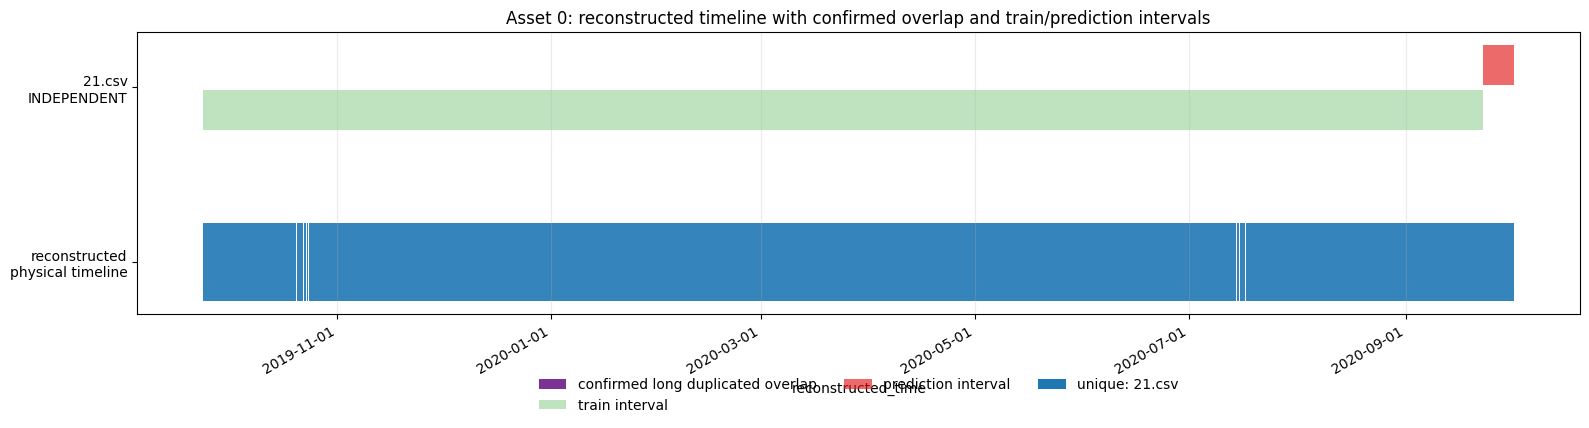

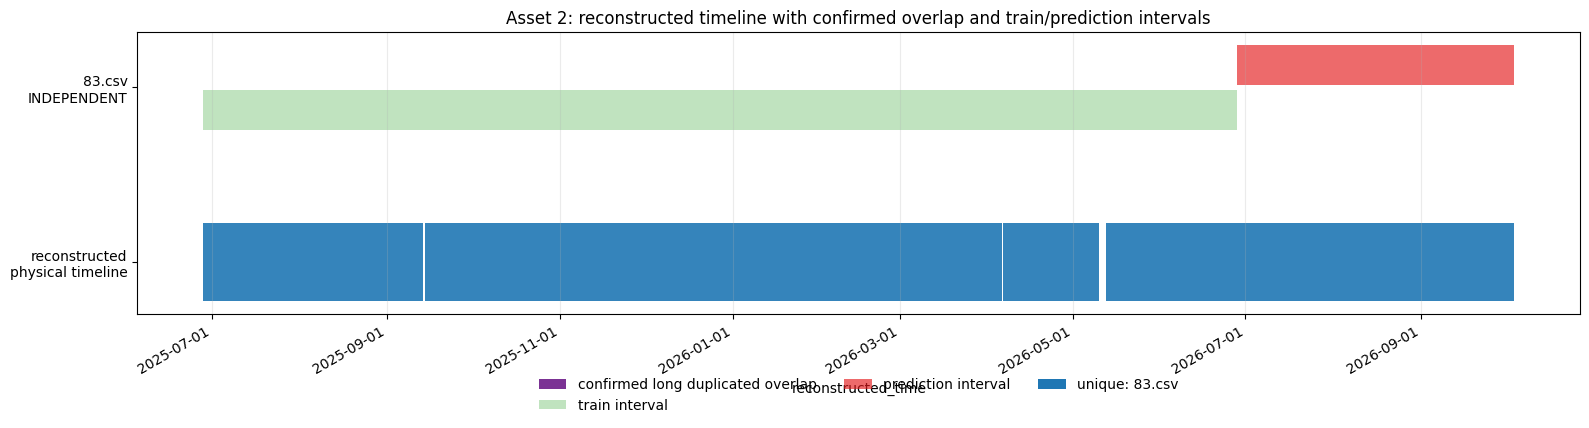

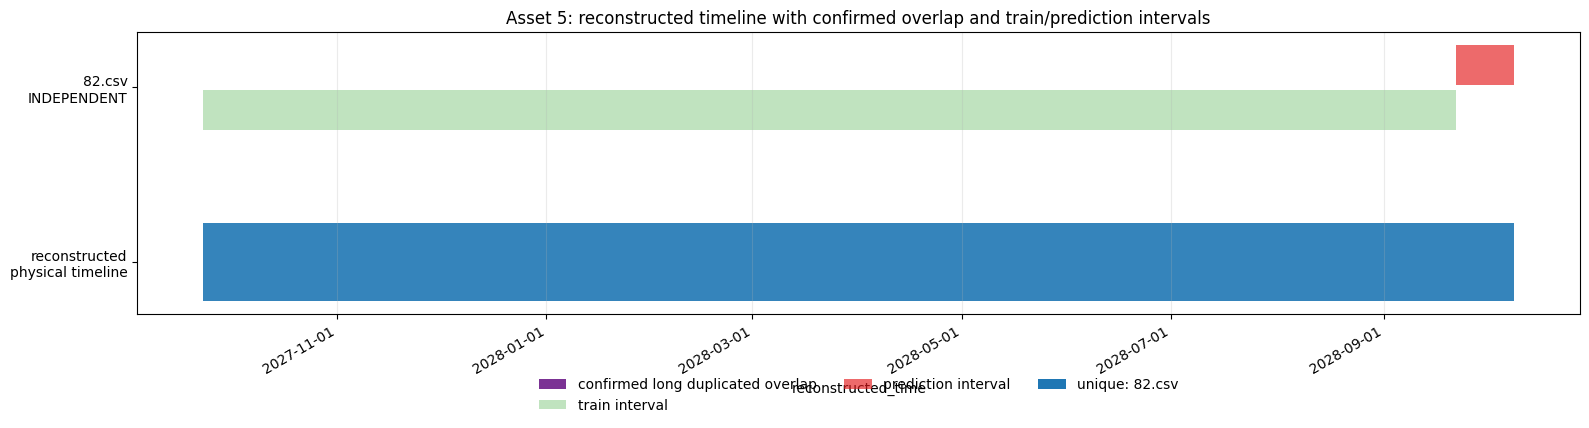

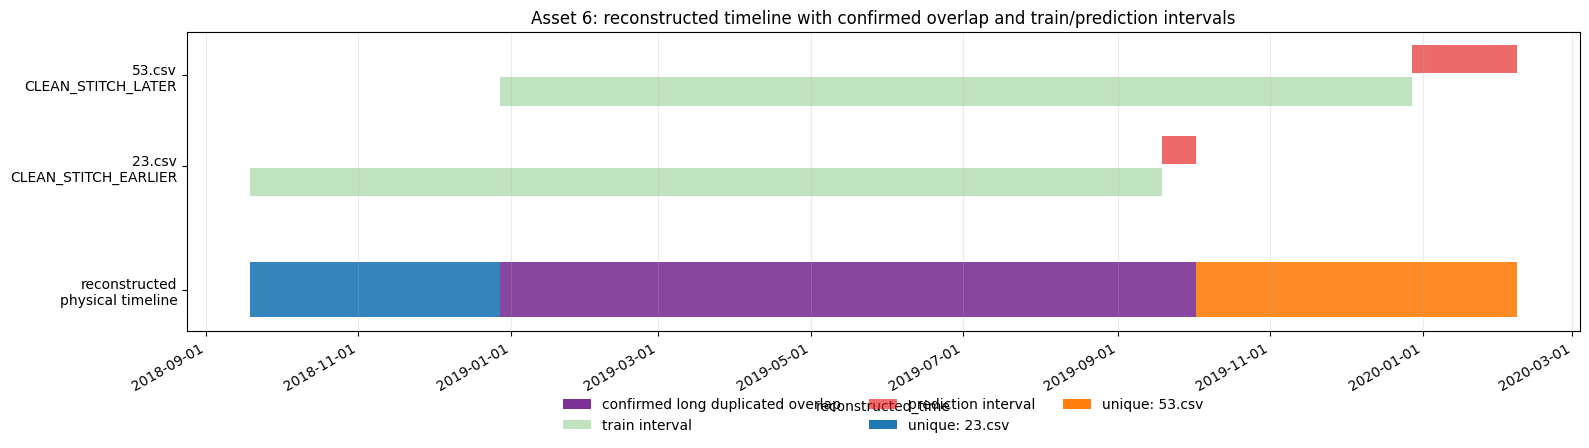

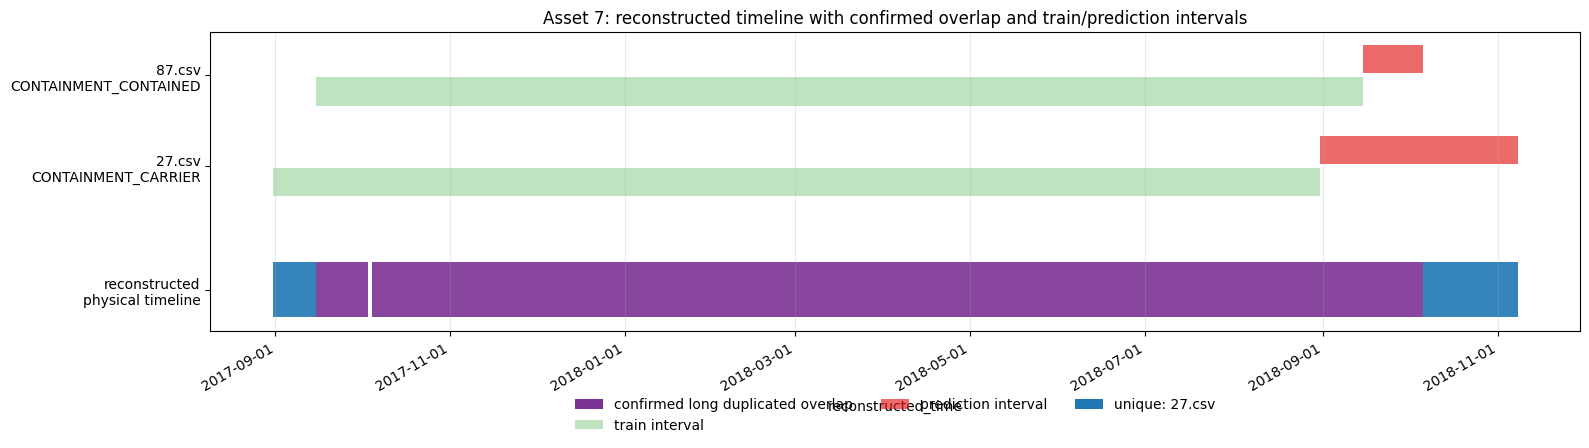

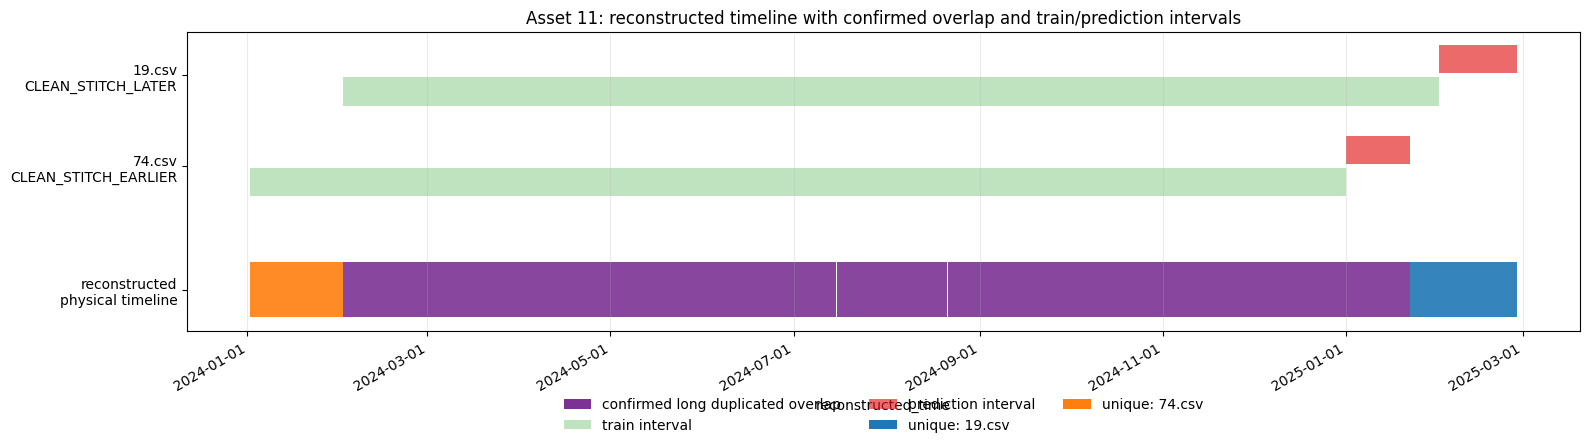

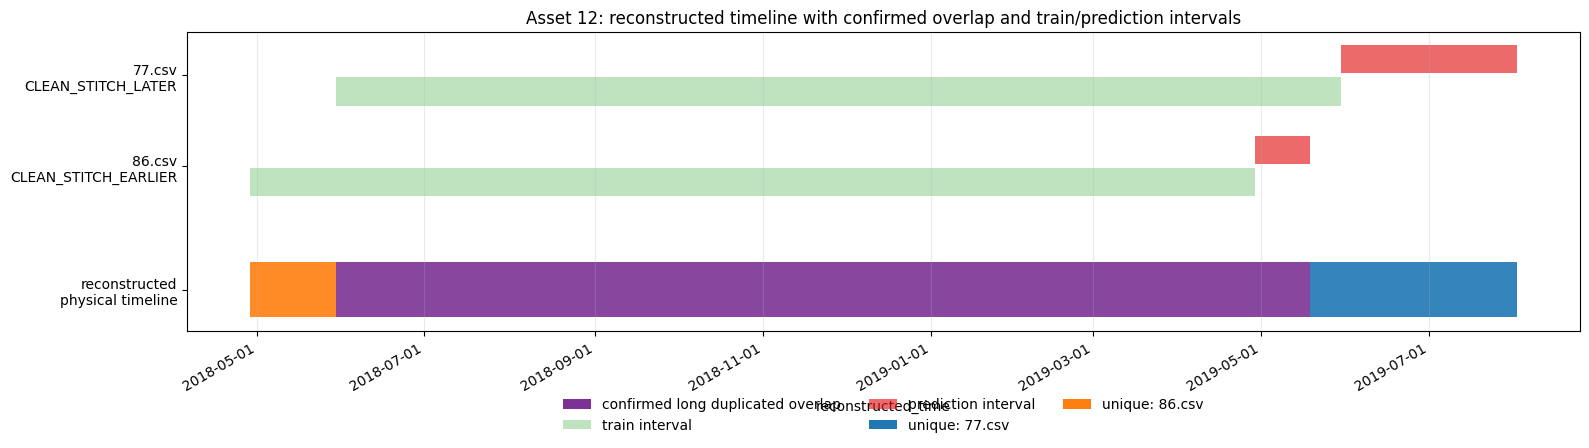

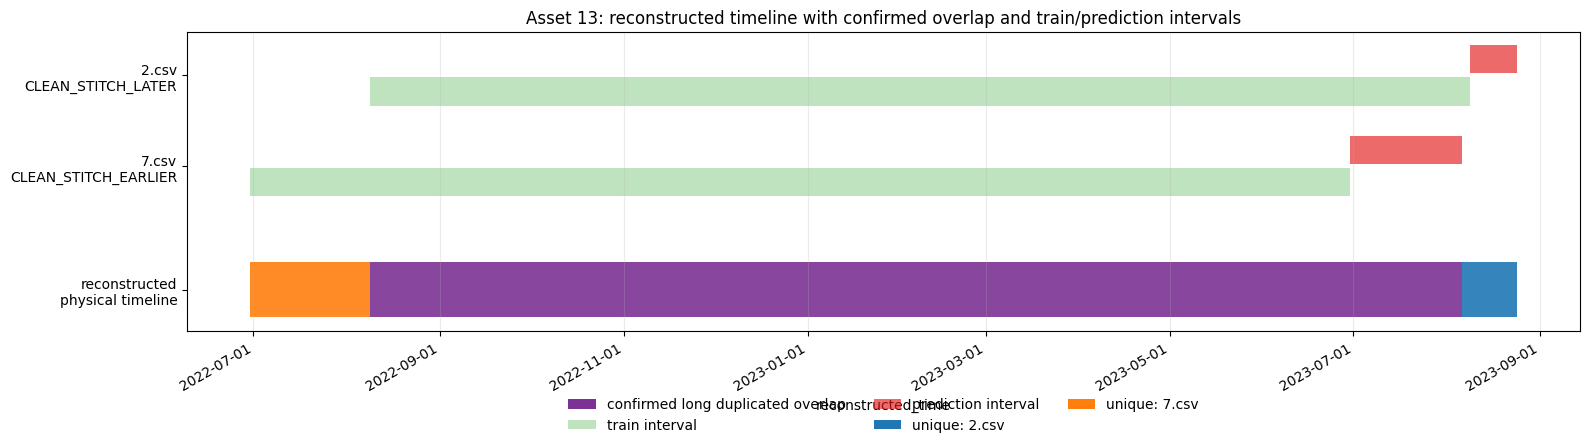

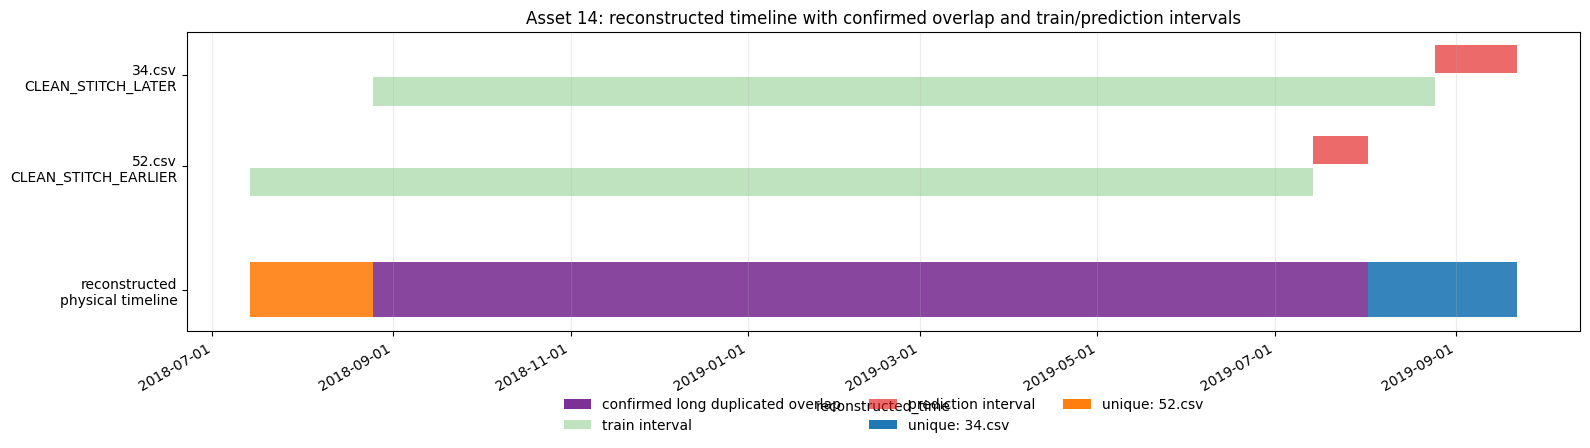

In [ ]:
# =========================================================
# Plot reconstructed timeline
# 只根据 pair_diag 确认的长 overlap block 标紫色
# 不依赖 is_confirmed_overlap
#
# 需要已有变量：
#   df_reconstructed
#   event_mapping
#   pair_diag
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch


def compress_segments(df, label_col):
    """
    把连续相同 label 的 row 压缩成时间段。
    如果 reconstructed_time 中间 >10min，也切开，显示真实 gap。
    """
    x = df.copy().sort_values("reconstructed_time").reset_index(drop=True)

    block_id = (
        (x[label_col] != x[label_col].shift()) |
        (x["reconstructed_time"].diff() > pd.Timedelta("10min"))
    ).cumsum()

    seg = (
        x.groupby(block_id)
        .agg(
            start_time=("reconstructed_time", "min"),
            end_time=("reconstructed_time", "max"),
            label=(label_col, "first"),
            n_rows=("reconstructed_time", "size"),
        )
        .reset_index(drop=True)
    )

    seg["end_time"] = seg["end_time"] + pd.Timedelta("10min")
    return seg


def add_overlap_label_from_pair_diag(df_asset, pair_diag_asset):
    """
    根据 pair_diag 的 a_start/a_end/b_start/b_end，
    只把确认过的长 overlap block 标成 confirmed overlap。
    不使用 all_source_sessions。
    """
    df = df_asset.copy()

    df["segment_label"] = "unique: " + df["source_session_id"].astype(str)

    confirmed = pair_diag_asset[
        pair_diag_asset["stitching_status"].isin(["CLEAN_STITCH", "CONTAINMENT"])
    ]

    for _, r in confirmed.iterrows():
        sid_a = r["session_a"]
        sid_b = r["session_b"]

        a_start, a_end = int(r["a_start"]), int(r["a_end"])
        b_start, b_end = int(r["b_start"]), int(r["b_end"])

        mask_a = (
            (df["source_session_id"] == sid_a) &
            (df["source_pos"].between(a_start, a_end))
        )

        mask_b = (
            (df["source_session_id"] == sid_b) &
            (df["source_pos"].between(b_start, b_end))
        )

        df.loc[mask_a | mask_b, "segment_label"] = "confirmed overlap"

    return df


def plot_asset_reconstructed_timeline(asset_id, df_reconstructed, event_mapping, pair_diag):
    df = df_reconstructed[df_reconstructed["asset_id"] == asset_id].copy()
    ev = event_mapping[event_mapping["asset_id"] == asset_id].copy()
    pdg = pair_diag[pair_diag["asset_id"] == asset_id].copy()

    if df.empty:
        raise ValueError(f"No reconstructed data for asset {asset_id}")

    df = df.sort_values("reconstructed_time").reset_index(drop=True)

    # 核心：从 pair_diag 动态生成 confirmed overlap label
    df = add_overlap_label_from_pair_diag(df, pdg)

    seg = compress_segments(df, "segment_label")

    # ---------- colors ----------
    unique_labels = sorted([
        x for x in seg["label"].unique()
        if x != "confirmed overlap"
    ])

    cmap = plt.get_cmap("tab10")

    color_map = {
        "confirmed overlap": "#7b3294",  # 紫色：确认的长重复 overlap
    }

    for i, lab in enumerate(unique_labels):
        color_map[lab] = cmap(i % 10)

    fig_height = max(4.5, 1.1 * len(ev) + 2.5)
    fig, ax = plt.subplots(figsize=(16, fig_height))

    # ---------- reconstructed physical timeline ----------
    y_timeline = 0
    h = 0.55

    for _, r in seg.iterrows():
        start = mdates.date2num(r["start_time"])
        width = mdates.date2num(r["end_time"]) - start

        ax.broken_barh(
            [(start, width)],
            (y_timeline, h),
            facecolors=color_map[r["label"]],
            edgecolors="none",   # 不画黑边，避免 gap 边界看起来像重复线
            linewidth=0,
            alpha=0.9,
        )

    # ---------- event train / prediction lanes ----------
    y_base = 1.2
    y_step = 0.9

    ev = ev.sort_values(["prediction_start_time", "session_id"]).reset_index(drop=True)

    for i, r in ev.iterrows():
        y = y_base + i * y_step

        # train interval
        if pd.notna(r["train_start_time"]) and pd.notna(r["train_end_time"]):
            start = mdates.date2num(r["train_start_time"])
            end = mdates.date2num(r["train_end_time"] + pd.Timedelta("10min"))

            ax.broken_barh(
                [(start, end - start)],
                (y, 0.28),
                facecolors="#4daf4a",
                edgecolors="none",
                alpha=0.35,
            )

        # prediction interval
        if pd.notna(r["prediction_start_time"]) and pd.notna(r["prediction_end_time"]):
            start = mdates.date2num(r["prediction_start_time"])
            end = mdates.date2num(r["prediction_end_time"] + pd.Timedelta("10min"))

            ax.broken_barh(
                [(start, end - start)],
                (y + 0.32, 0.28),
                facecolors="#e41a1c",
                edgecolors="none",
                alpha=0.65,
            )

    # ---------- y labels ----------
    yticks = [y_timeline + h / 2]
    ylabels = ["reconstructed\nphysical timeline"]

    for i, r in ev.iterrows():
        yticks.append(y_base + i * y_step + 0.3)
        ylabels.append(f"{r['session_id']}\n{r['mapping_type']}")

    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels)

    # ---------- x axis ----------
    ax.xaxis_date()
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=5, maxticks=10))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

    ax.set_xlabel("reconstructed_time")
    ax.set_title(
        f"Asset {asset_id}: reconstructed timeline with confirmed overlap and train/prediction intervals"
    )

    ax.grid(axis="x", alpha=0.25)

    # ---------- legend ----------
    legend_items = [
        Patch(facecolor="#7b3294", edgecolor="none", label="confirmed long duplicated overlap"),
        Patch(facecolor="#4daf4a", alpha=0.35, label="train interval"),
        Patch(facecolor="#e41a1c", alpha=0.65, label="prediction interval"),
    ]

    for lab in unique_labels:
        legend_items.append(
            Patch(facecolor=color_map[lab], edgecolor="none", label=lab)
        )

    ax.legend(
        handles=legend_items,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.18),
        ncol=3,
        frameon=False,
    )

    plt.tight_layout()
    plt.show()


for aid in sorted(df_reconstructed["asset_id"].unique()):
    plot_asset_reconstructed_timeline(
        aid,
        df_reconstructed=df_reconstructed,
        event_mapping=event_mapping,
        pair_diag=pair_diag,
    )

In [ ]:
# =========================================================
# Freeze reconstructed observed database v1
# =========================================================

import os
import json
import pandas as pd

FREEZE_DIR = "/content/drive/MyDrive/windfarmB_reconstructed_observed_db_v1"
os.makedirs(FREEZE_DIR, exist_ok=True)

# 1) 主数据：重构后的 observed physical timeline
df_reconstructed.to_parquet(
    os.path.join(FREEZE_DIR, "df_reconstructed.parquet"),
    index=False
)

# 2) event mapping：原始 event/session 的 train/prediction 区间
event_mapping.to_parquet(
    os.path.join(FREEZE_DIR, "event_mapping.parquet"),
    index=False
)

# 3) pair diagnosis：重构依据
pair_diag.to_parquet(
    os.path.join(FREEZE_DIR, "pair_diag.parquet"),
    index=False
)

# 4) session load check：原始读取检查
session_load_check.to_parquet(
    os.path.join(FREEZE_DIR, "session_load_check.parquet"),
    index=False
)

# 5) SCADA_HASH_COLS：hash 用到的列
with open(os.path.join(FREEZE_DIR, "SCADA_HASH_COLS.json"), "w") as f:
    json.dump(SCADA_HASH_COLS, f, indent=2)

# 6) session_mapping_type：tuple key 转成字符串保存
session_mapping_type_save = {
    f"{aid}|{sid}": mtype
    for (aid, sid), mtype in session_mapping_type.items()
}

with open(os.path.join(FREEZE_DIR, "session_mapping_type.json"), "w") as f:
    json.dump(session_mapping_type_save, f, indent=2)

# 7) manifest：冻结说明
manifest = {
    "version": "windfarmB_reconstructed_observed_db_v1",
    "description": "Reconstructed observed-row physical timeline before 10min reindex, gap labeling, imputation, clipping, scaling, and windowing.",
    "main_data": "df_reconstructed.parquet",
    "event_mapping": "event_mapping.parquet",
    "pair_diag": "pair_diag.parquet",
    "important_note": "Original train_test is source metadata only. Modeling splits must be derived from event_mapping.",
    "asset7_note": "Asset 7: 27.csv carries 87.csv. 87.csv is CONTAINMENT_CONTAINED and should not be appended into reconstructed_by_asset[7].",
}

with open(os.path.join(FREEZE_DIR, "manifest.json"), "w") as f:
    json.dump(manifest, f, indent=2)

print("Frozen reconstructed observed database saved to:")
print(FREEZE_DIR)

Frozen reconstructed observed database saved to:
/content/drive/MyDrive/windfarmB_reconstructed_observed_db_v1


In [13]:
# =========================================================
# Diagnose duplicate reconstructed timestamps
# =========================================================

dup_time_rows = []

for aid, df in reconstructed_by_asset.items():
    dup_mask = df["time_stamp"].duplicated(keep=False)
    n_dup_rows = int(dup_mask.sum())
    n_dup_timestamps = int(df.loc[dup_mask, "time_stamp"].nunique())

    if n_dup_rows > 0:
        dup_time_rows.append({
            "asset_id": aid,
            "n_dup_rows": n_dup_rows,
            "n_dup_timestamps": n_dup_timestamps,
            "time_min": df.loc[dup_mask, "time_stamp"].min(),
            "time_max": df.loc[dup_mask, "time_stamp"].max(),
        })

dup_time_report = pd.DataFrame(dup_time_rows)

display(dup_time_report)

,asset_id,n_dup_rows,n_dup_timestamps,time_min,time_max
0,2,10,1,2025-07-02 10:40:00,2025-07-02 10:40:00


In [14]:
# =========================================================
# 2) 把 asset 2 / 2025-07-02 10:40:00 这 10 行完整调出来
# =========================================================

aid = 2
bad_time = pd.Timestamp("2025-07-02 10:40:00")

bad_rows = (
    reconstructed_by_asset[aid]
    .loc[lambda x: x["time_stamp"].eq(bad_time)]
    .sort_values(["physical_order_index"])
    .reset_index(drop=True)
)

print("n_rows =", len(bad_rows))
print("all columns of these duplicated-timestamp rows:")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
display(bad_rows)

n_rows = 10
all columns of these duplicated-timestamp rows:


,time_stamp,asset_id,id,train_test,status_type_id,sensor_0_avg,sensor_0_max,sensor_0_min,sensor_0_std,sensor_1_avg,sensor_1_max,sensor_1_min,sensor_1_std,sensor_2_avg,sensor_2_max,sensor_2_min,sensor_2_std,sensor_3_avg,sensor_3_max,sensor_3_min,sensor_3_std,sensor_4_avg,sensor_4_max,sensor_4_min,sensor_4_std,sensor_5_avg,sensor_5_max,sensor_5_min,sensor_5_std,sensor_6_avg,sensor_6_max,sensor_6_min,sensor_6_std,sensor_7_avg,sensor_7_max,sensor_7_min,sensor_7_std,sensor_8_avg,sensor_8_max,sensor_8_min,sensor_8_std,sensor_9_avg,sensor_9_max,sensor_9_min,sensor_9_std,sensor_10_avg,sensor_10_max,sensor_10_min,sensor_10_std,reactive_power_11_avg,reactive_power_11_max,reactive_power_11_min,reactive_power_11_std,sensor_12_avg,sensor_12_max,sensor_12_min,sensor_12_std,sensor_13_avg,sensor_13_max,sensor_13_min,sensor_13_std,sensor_14_avg,sensor_14_max,sensor_14_min,sensor_14_std,sensor_15_avg,sensor_15_max,sensor_15_min,sensor_15_std,sensor_16_avg,sensor_16_max,sensor_16_min,sensor_16_std,sensor_17_avg,sensor_17_max,sensor_17_min,sensor_17_std,sensor_18_avg,sensor_18_max,sensor_18_min,sensor_18_std,sensor_19_avg,sensor_19_max,sensor_19_min,sensor_19_std,sensor_20_avg,sensor_20_max,sensor_20_min,sensor_20_std,sensor_21_avg,sensor_21_max,sensor_21_min,sensor_21_std,sensor_22_avg,sensor_22_max,sensor_22_min,sensor_22_std,sensor_23_avg,sensor_23_max,sensor_23_min,sensor_23_std,sensor_24_avg,sensor_24_max,sensor_24_min,sensor_24_std,sensor_25_avg,sensor_25_max,sensor_25_min,sensor_25_std,sensor_26_avg,sensor_26_max,sensor_26_min,sensor_26_std,sensor_27_avg,sensor_27_max,sensor_27_min,sensor_27_std,sensor_28_avg,sensor_28_max,sensor_28_min,sensor_28_std,sensor_29_avg,sensor_29_max,sensor_29_min,sensor_29_std,sensor_30_avg,sensor_30_max,sensor_30_min,sensor_30_std,sensor_31_avg,sensor_31_max,sensor_31_min,sensor_31_std,sensor_32_avg,sensor_32_max,sensor_32_min,sensor_32_std,sensor_33_avg,sensor_33_max,sensor_33_min,sensor_33_std,sensor_34_avg,sensor_34_max,sensor_34_min,sensor_34_std,sensor_35_avg,sensor_35_max,sensor_35_min,sensor_35_std,sensor_36_avg,sensor_36_max,sensor_36_min,sensor_36_std,sensor_37_avg,sensor_37_max,sensor_37_min,sensor_37_std,sensor_38_avg,sensor_38_max,sensor_38_min,sensor_38_std,sensor_39_avg,sensor_39_max,sensor_39_min,sensor_39_std,sensor_40_avg,sensor_40_max,sensor_40_min,sensor_40_std,sensor_41_avg,sensor_41_max,sensor_41_min,sensor_41_std,sensor_42_avg,sensor_42_max,sensor_42_min,sensor_42_std,sensor_43_avg,sensor_43_max,sensor_43_min,sensor_43_std,sensor_44_avg,sensor_44_max,sensor_44_min,sensor_44_std,sensor_45_avg,sensor_45_max,sensor_45_min,sensor_45_std,sensor_46_avg,sensor_46_max,sensor_46_min,sensor_46_std,sensor_47_avg,sensor_47_max,sensor_47_min,sensor_47_std,sensor_48_avg,sensor_48_max,sensor_48_min,sensor_48_std,sensor_49_avg,sensor_49_max,sensor_49_min,sensor_49_std,sensor_50_avg,sensor_50_max,sensor_50_min,sensor_50_std,sensor_51_avg,sensor_51_max,sensor_51_min,sensor_51_std,sensor_52_avg,sensor_52_max,sensor_52_min,sensor_52_std,sensor_53_avg,sensor_53_max,sensor_53_min,sensor_53_std,sensor_54_avg,sensor_54_max,sensor_54_min,sensor_54_std,sensor_55_avg,sensor_55_max,sensor_55_min,sensor_55_std,sensor_56_avg,sensor_56_max,sensor_56_min,sensor_56_std,sensor_57_avg,sensor_57_max,sensor_57_min,sensor_57_std,power_58_avg,power_58_max,power_58_min,power_58_std,wind_speed_59_avg,wind_speed_59_max,wind_speed_59_min,wind_speed_59_std,wind_speed_60_avg,wind_speed_60_max,wind_speed_60_min,wind_speed_60_std,wind_speed_61_avg,wind_speed_61_max,wind_speed_61_min,wind_speed_61_std,power_62_avg,power_62_max,power_62_min,power_62_std,session_id,source_pos,source_row_uid,scada_hash,source_asset_id,source_session_id,source_time_stamp,physical_order_index,reconstructed_time,all_source_sessions
0,2025-07-02 10:40:00,2,640,train,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.